In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
import matplotlib as mpl
import lightkurve as lk
import matplotlib.patches as patches

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

# --- Edit these paths as needed ---
DATA_FILE = 'v1/umap_age_model_multiscale_bprp-4.0_data.npz'
PHOT_CSV  = '../../data/phot_all.csv'

data      = np.load(DATA_FILE, allow_pickle=True)
embedding = data['embedding']    # (N, 2)
ages      = data['ages']         # (N,) Myr
bprp0     = data['bprp0']        # (N,)
gaia_ids  = data['gaia_ids']     # (N,) str
tic_ids   = data['tic_ids']      # (N,) int64
sectors = data['sectors']        # (N,) int64

print(f'Loaded {len(ages)} samples')
print(f'Embedding shape: {embedding.shape}')
print(f'Age range:   {ages.min():.1f} – {ages.max():.1f} Myr')
print(f'BPRP0 range: {bprp0.min():.2f} – {bprp0.max():.2f}')

Loaded 7154 samples
Embedding shape: (7154, 2)
Age range:   1.6 – 3870.0 Myr
BPRP0 range: -0.26 – 5.03


## UMAP Latent Space Analysis

Load pre-computed UMAP embeddings and replot with different metadata coloring.

The `.npz` file contains:
- `embedding`: (N, 2) UMAP coordinates
- `ages`: (N,) ages in Myr
- `bprp0`: (N,) Gaia BP-RP color
- `latent_vectors`: (N, D) raw latent features
- `gaia_ids`: (N,) GaiaDR3_ID strings
- `tic_ids`: (N,) TESS TIC IDs (int64)

To join additional metadata, use `gaia_ids` to merge against `data/phot_all.csv`.

In [3]:
# Join additional metadata from phot_all.csv via GaiaDR3_ID
phot = pd.read_csv(PHOT_CSV)
phot['GaiaDR3_ID'] = phot['GaiaDR3_ID'].astype(str)

df = pd.DataFrame({'GaiaDR3_ID': gaia_ids, 'tic': tic_ids})
df = df.merge(phot, on='GaiaDR3_ID', how='left')

print(f'Columns available: {df.columns.tolist()}')

Columns available: ['GaiaDR3_ID', 'tic', 'num_refs', 'Prot', 'mem_prob_val', 'age_Myr', 'parallax', 'parallax_error', 'G0', 'G0_err', 'BP0', 'BP0_err', 'RP0', 'RP0_err', 'BPRP0', 'BPRP0_err']


### Choose random stars from specific regions of UMAP space as an example

#### Bottom left

In [236]:
random_gid

'661283199601699328'

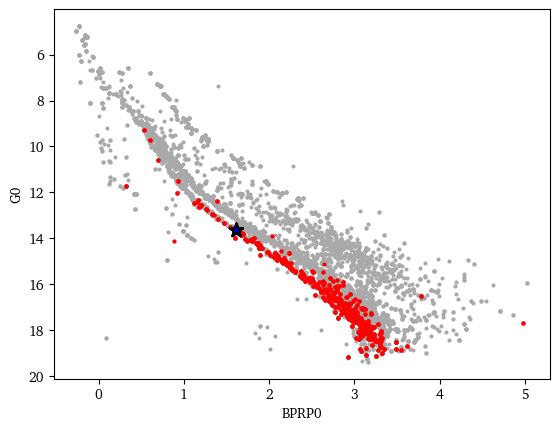

In [4]:
mask_x = (embedding[:, 0] < 0)
mask_y = (embedding[:, 1] < -2)
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_index = np.random.choice(matching_indices[0])
random_gid = gaia_ids[random_index]
random_gid_1 = '661283199601699328'
random_index_1 = 4447


# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_1, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_1, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Top blob

In [206]:
random_gid

'68283421593270400'

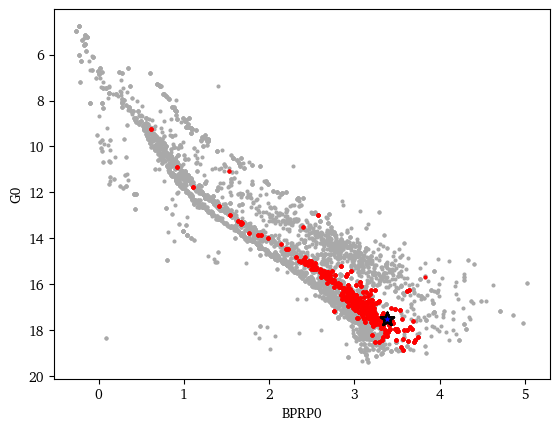

In [5]:
mask_x = (embedding[:, 0] < 4) & (embedding[:, 0] > 2)
mask_y = embedding[:, 1] > 6
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_2 = '68283421593270400'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_2, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_2, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Right (young)

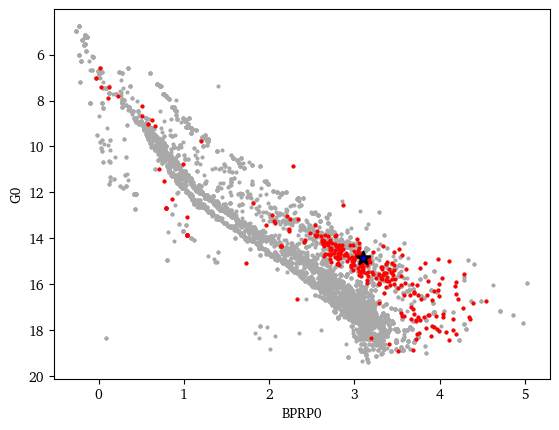

In [6]:
mask_x = (embedding[:, 0] < 8) & (embedding[:, 0] > 7)
mask_y = embedding[:, 1] > 4
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_3 = '6050538893392363136'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_3, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_3, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Middle

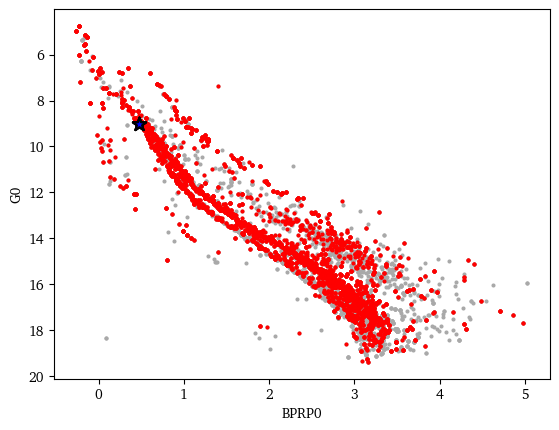

In [7]:
mask_x = (embedding[:, 0] < 10) & (embedding[:, 0] > 2)
mask_y = (embedding[:, 1] > -2) & (embedding[:, 1] < 4)
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_4 = '659466222275521792'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_4, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_4, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

### Plot latent space

In [11]:
def umap_scatter(c, label, log_scale=False, cmap='viridis_r',
                 bprp0_min=None, bprp0_max=None,
                 point_size=10, alpha=0.5, figsize=(10, 6)):
    """Plot UMAP colored by an arbitrary array, with optional BPRP0 filtering."""
    c = np.asarray(c, dtype=float)
    mask = np.ones(len(embedding), dtype=bool)
    if bprp0_min is not None:
        mask &= (bprp0 >= bprp0_min)
    if bprp0_max is not None:
        mask &= (bprp0 <= bprp0_max)
    mask &= ~np.isnan(c)

    x_p = embedding[mask, 0]
    y_p = embedding[mask, 1]
    c_p = c[mask]

    norm = LogNorm(vmin=c_p.min(), vmax=c_p.max()) if log_scale else Normalize(vmin=c_p.min(), vmax=c_p.max())

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(x_p, y_p, c=c_p, cmap=cmap, norm=norm,
                    s=point_size, alpha=alpha, rasterized=True)
    
    # Set colorbar on separate points to have separate alpha
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label(label, fontsize=18)
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

    info_lines = [f'N = {mask.sum()}']
    if bprp0_min is not None or bprp0_max is not None:
        info_lines.append(f'BPRP0: {bprp0_min or ""}–{bprp0_max or ""}')
    # ax.text(0.02, 0.98, '\n'.join(info_lines), transform=ax.transAxes, fontsize=11,
    #         va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    return fig, ax

### Stellar age

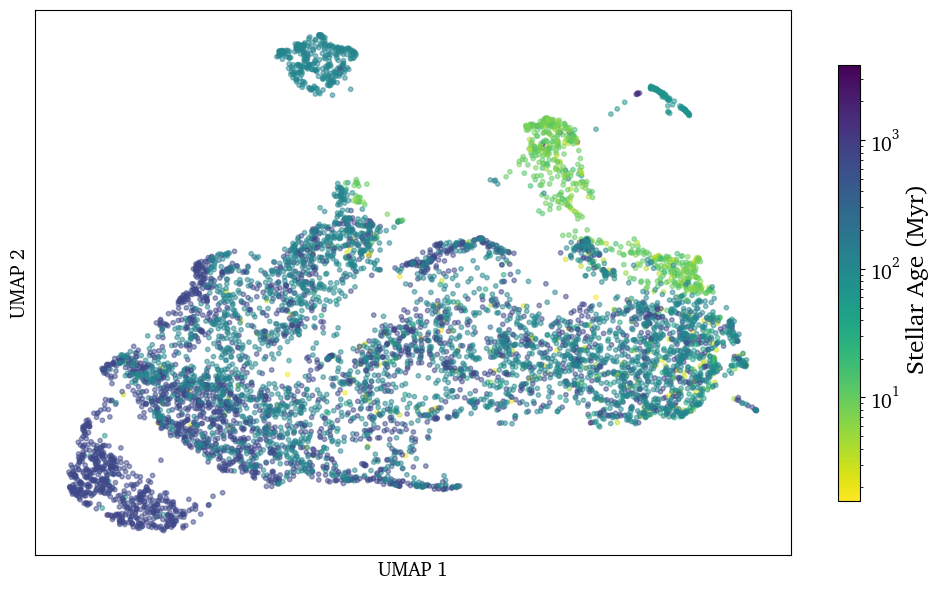

In [12]:
fig, ax = umap_scatter(ages, ' Stellar Age (Myr)', log_scale=True)
# ax.set_title('UMAP – Stellar Age')


plt.show()

### Age with BPRP0 filter to restrict the plotted points to a colour range.

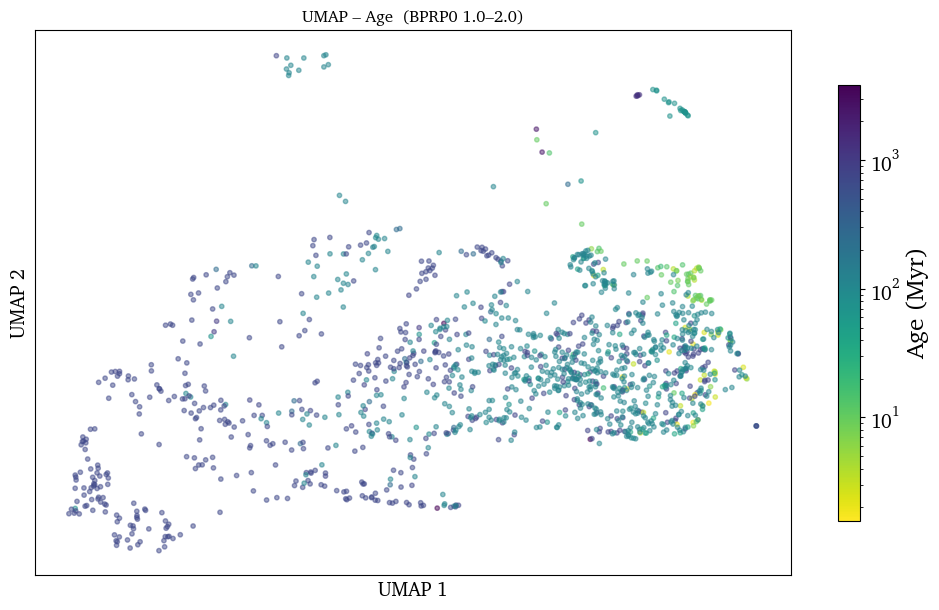

In [13]:
fig, ax = umap_scatter(ages, 'Age (Myr)', log_scale=True,
                       bprp0_min=1.0, bprp0_max=2.0)
ax.set_title('UMAP – Age  (BPRP0 1.0–2.0)')
plt.show()

### BPRP0 color

/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_93417/1598810239.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Charter.
  plt.tight_layout()
/Users/philvanlane/opt/anaconda3/envs/default-py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)


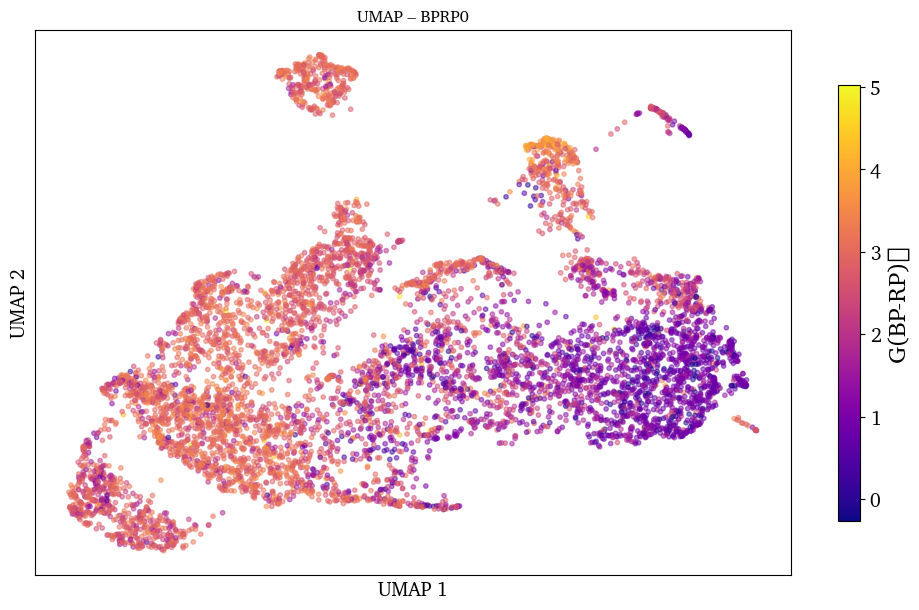

In [14]:
fig, ax = umap_scatter(bprp0, 'G(BP-RP)₀', log_scale=False, cmap='plasma')
ax.set_title('UMAP – BPRP0')
plt.show()

### Color by any phot_all.csv column `Prot`, `parallax`, `G0`, `BP0`, `RP0`, `teff_gspphot`, etc.

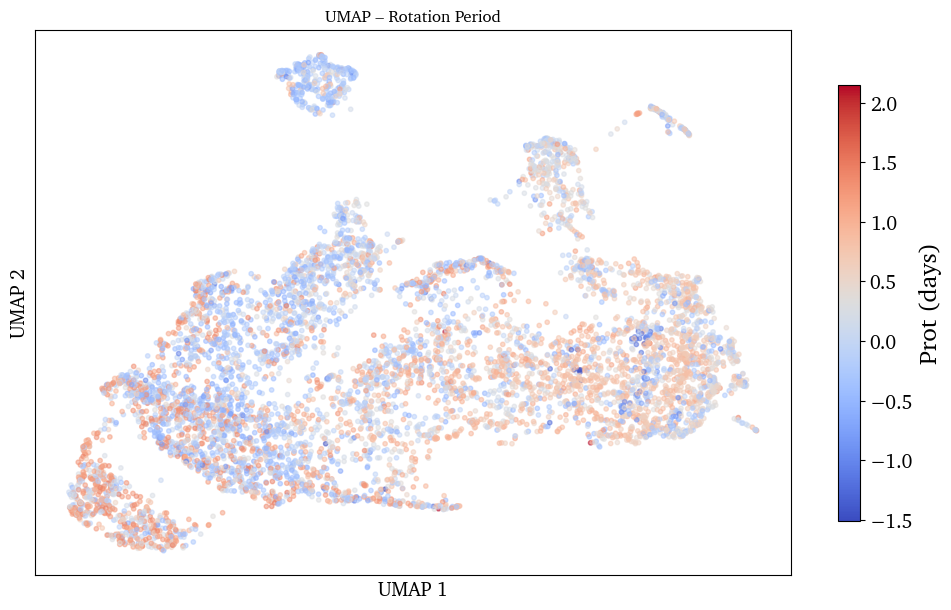

In [55]:
# Example: rotation period
fig, ax = umap_scatter(np.log10(df['Prot'].values), 'Prot (days)', log_scale=False, cmap='coolwarm')
ax.set_title('UMAP – Rotation Period')
plt.show()

## Find CMD examples

In [16]:
# Blue, bright, 97 Myr
dr3id_1 = '64933759417769984'

# Red, maybe PMS, 760 Myr
dr3id_2 = '145668974102570624'

# Red 718 Myr
dr3id_3 = '658156527832150400'

In [18]:
df_1 = df.loc[(df['GaiaDR3_ID'] == random_gid_1)]
BPRP0_1 = df_1['BPRP0'].values[0]
G0_1 = df_1['G0'].values[0]

df_2 = df.loc[(df['GaiaDR3_ID'] == random_gid_2)]
BPRP0_2 = df_2['BPRP0'].values[0]
G0_2 = df_2['G0'].values[0]

df_3 = df.loc[(df['GaiaDR3_ID'] == random_gid_3)]
BPRP0_3 = df_3['BPRP0'].values[0]
G0_3 = df_3['G0'].values[0]

df_4 = df.loc[(df['GaiaDR3_ID'] == random_gid_4)]
BPRP0_4 = df_4['BPRP0'].values[0]
G0_4 = df_4['G0'].values[0]

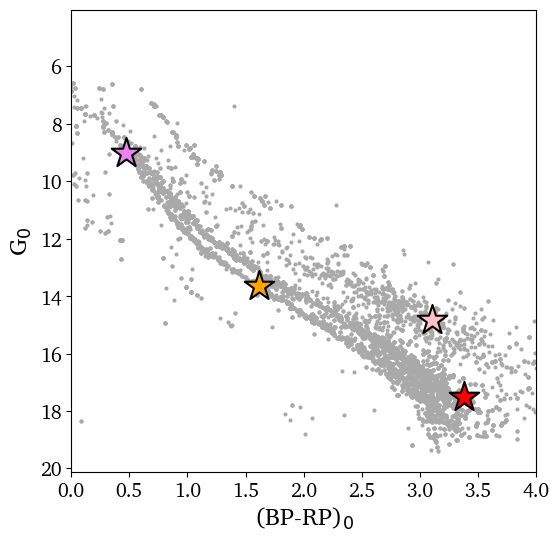

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')

plt.scatter(BPRP0_1, G0_1, s=500, alpha=1, c='orange',marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_2, G0_2, s=500, alpha=1, c='red', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_3, G0_3, s=500, alpha=1, c='pink', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_4, G0_4, s=500, alpha=1, c='violet', marker='*', edgecolor='black', linewidth=1.5)

plt.gca().invert_yaxis()
plt.xlim(0,4)
plt.xlabel(r'(BP-RP)$_0$',fontsize=18)
plt.ylabel(r'G$_0$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

### Plot UMAP with specific points

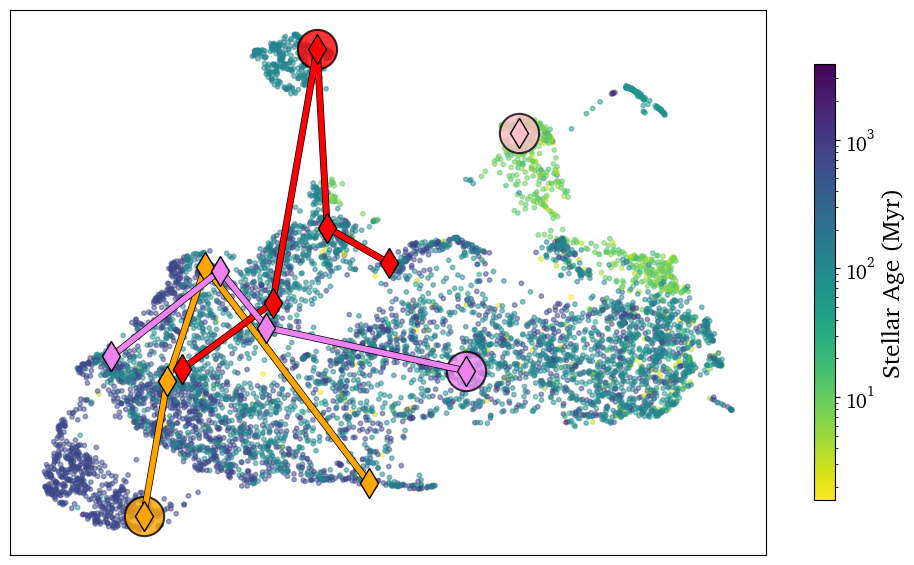

In [29]:
fig, ax = umap_scatter(ages, 'Stellar Age (Myr)', log_scale=True)
# ax.set_title('UMAP – Stellar Age')
umap_ind_1 = np.where(gaia_ids == random_gid_1)[0]
umap_ind_2 = np.where(gaia_ids == random_gid_2)[0]
umap_ind_3 = np.where(gaia_ids == random_gid_3)[0]
umap_ind_4 = np.where(gaia_ids == random_gid_4)[0]

umap_1 = embedding[umap_ind_1]
umap_1_sorted = umap_1[umap_1[:, 0].argsort()]
plt.scatter(umap_1_sorted[0,0], umap_1_sorted[0,1], s=800, alpha=0.8,
            color='orange', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='orange', marker='d',
            markeredgecolor='black',linewidth=4)

umap_2 = embedding[umap_ind_2]
umap_2_sorted = umap_2[umap_2[:, 0].argsort()]
plt.scatter(umap_2_sorted[2,0], umap_2_sorted[2,1], s=800, alpha=0.8,
            color='red', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='red', marker='d',
            markeredgecolor='black',linewidth=4)

umap_3 = embedding[umap_ind_3]
umap_3_sorted = umap_3[umap_3[:, 0].argsort()]
plt.scatter(umap_3_sorted[0,0], umap_3_sorted[0,1], s=800, alpha=0.8,
            color='pink', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='pink', marker='d',
            markeredgecolor='black',linewidth=4)

umap_4 = embedding[umap_ind_4]
umap_4_sorted = umap_4[umap_4[:, 0].argsort()]
plt.scatter(umap_4_sorted[3,0], umap_4_sorted[3,1], s=800, alpha=0.8,
            color='violet', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='violet', marker='d',
            markeredgecolor='black',linewidth=4)

ax.set_xlabel('', fontsize=18)
ax.set_ylabel('', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## Get Example Light Curves

In [32]:
# Choose which points to use

umap_1_ref = umap_ind_1[1]      # left most orange point
umap_2_ref = umap_ind_2[0]      # top red point
umap_3_ref = umap_ind_3[0]      # pink point
umap_4_ref = umap_ind_4[0]      # right most yellow point

In [33]:
tic_1 = tic_ids[umap_1_ref]
sector_1 = sectors[umap_1_ref]
tic_2 = tic_ids[umap_2_ref]
sector_2 = sectors[umap_2_ref]
tic_3 = tic_ids[umap_3_ref]
sector_3 = sectors[umap_3_ref]
tic_4 = tic_ids[umap_4_ref]
sector_4 = sectors[umap_4_ref]

In [34]:
res_1 = lk.search_lightcurve(f"TIC {tic_1}", mission='TESS', author=['SPOC'],sector=sector_1,exptime=120)
lc_1 = res_1[0].download()
res_2 = lk.search_lightcurve(f"TIC {tic_2}", mission='TESS', author=['SPOC'],sector=sector_2,exptime=120)
lc_2 = res_2[0].download()
res_3 = lk.search_lightcurve(f"TIC {tic_3}", mission='TESS', author=['SPOC'],sector=sector_3,exptime=120)
lc_3 = res_3[0].download()
res_4 = lk.search_lightcurve(f"TIC {tic_4}", mission='TESS', author=['SPOC'],sector=sector_4,exptime=120)
lc_4 = res_4[0].download()

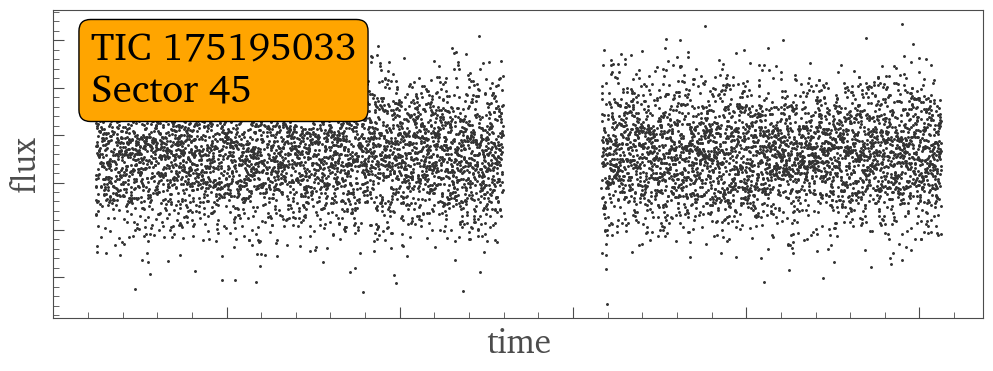

In [54]:
lc_thinned = lc_1[::2]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_1}\nSector {sector_1}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='orange', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

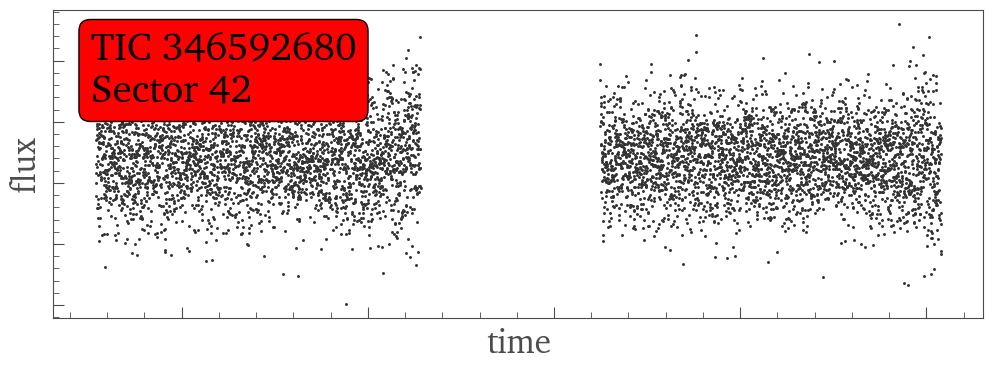

In [53]:
lc_thinned = lc_2[::2]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_2}\nSector {sector_2}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='red', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

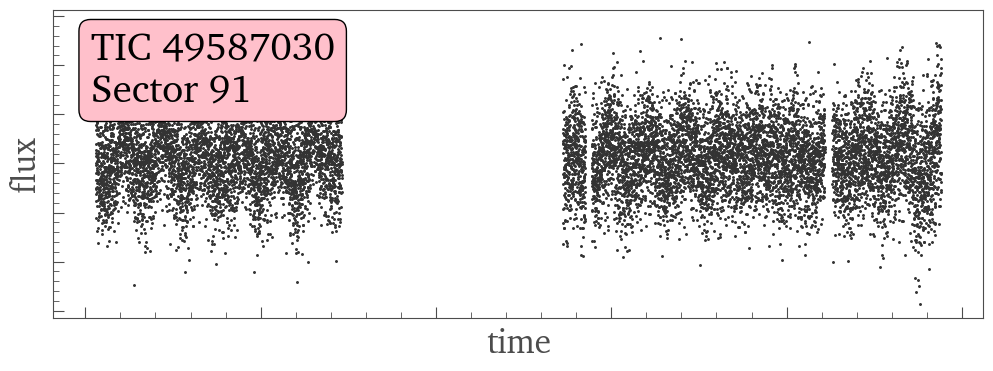

In [52]:
lc_thinned = lc_3[::1]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_3}\nSector {sector_3}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='pink', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

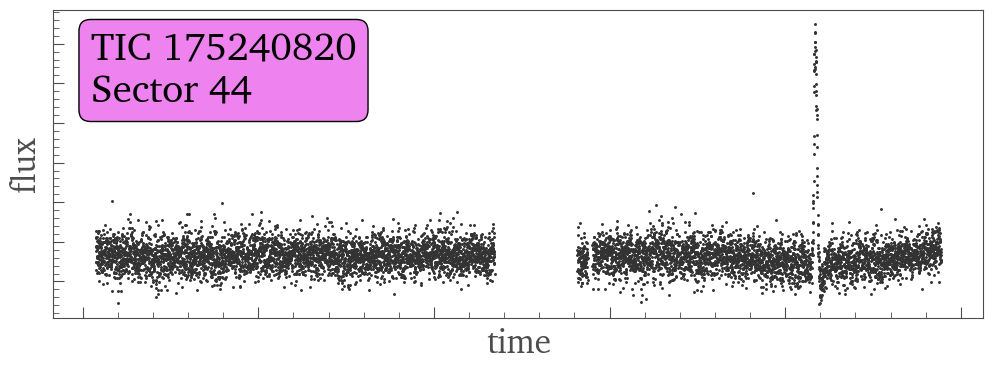

In [51]:
lc_thinned = lc_4[::2]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_4}\nSector {sector_4}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='violet', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

## Random plot for schematic

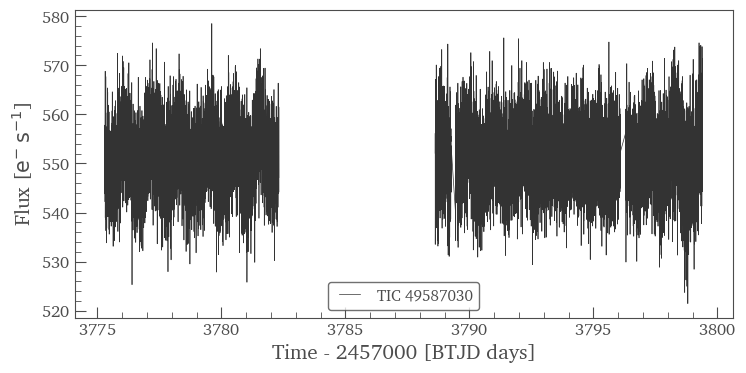

In [479]:
lc_3.plot()
plt.show()

In [483]:
phot.columns

Index(['GaiaDR3_ID', 'num_refs', 'Prot', 'age_Myr', 'parallax',
       'parallax_error', 'G0', 'G0_err', 'BP0', 'BP0_err', 'RP0', 'RP0_err',
       'BPRP0', 'BPRP0_err'],
      dtype='object')

In [490]:
df_test = df[['GaiaDR3_ID', 'tic','BPRP0']].sample(frac=0.1)
df_test['...'] = '...'
df_test

,GaiaDR3_ID,tic,BPRP0,...
6413,67054305033161344,149979913,2.975164,...
909,44388010264995200,435338054,3.645365,...
2452,64600813554014592,113982669,2.518392,...
1715,6049751196390570880,286075206,3.041236,...
2575,64891634380723712,440690662,2.194947,...
...,...,...,...,...
5993,66722660540945408,35156315,3.697476,...
4814,661486158278348160,331989648,3.083026,...
6954,69819027020489088,385552619,0.649584,...
1377,53251929411490688,14226920,2.463426,...


## Correlate points in UMAP space to parameters or Light Curve properties

In [99]:
def plot_umap_bounds(embedding, umap_xlim, umap_ylim):
    # Show bounding rectangle
    rect = patches.Rectangle(
        (umap_xlim[0], umap_ylim[0]),        # (x0, y0) lower-left corner
        umap_xlim[1] - umap_xlim[0],       # width
        umap_ylim[1] - umap_ylim[0],       # height
        edgecolor='navy',
        alpha=1,
        facecolor='none'
    )

    mask_x = (embedding[:, 0] < umap_xlim[1]) & (embedding[:, 0] > umap_xlim[0])
    mask_y = (embedding[:, 1] < umap_ylim[1]) & (embedding[:, 1] > umap_ylim[0])

    x_all = embedding[:, 0]
    y_all = embedding[:, 1]

    x_p = embedding[mask_x & mask_y, 0]
    y_p = embedding[mask_x & mask_y, 1]

    fig, ax = plt.subplots(figsize=(8,5))
    sc = ax.scatter(x_all,y_all, color='darkgrey', s=15, alpha=0.5, marker='.')
    sc = ax.scatter(x_p, y_p, color='violet', s=15, alpha=1, marker='.')
    ax.add_patch(rect)

    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    # ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()
    return (mask_x,mask_y)

In [86]:
def plot_cmd(mask_x, mask_y):
    matching_indices = np.where(mask_x & mask_y)
    matching_gids = gaia_ids[matching_indices]


    # Filter stars
    df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
    plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
    plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
    plt.gca().invert_yaxis()
    plt.xlabel('BPRP0')
    plt.ylabel('G0')
    plt.show()

In [96]:
def plot_prot(mask_x, mask_y):
    matching_indices = np.where(mask_x & mask_y)
    matching_gids = gaia_ids[matching_indices]


    # Filter stars
    df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
    plt.scatter(df['BPRP0'],np.log10(df['Prot']), s=15, alpha=1,c='darkgray',marker='.')
    plt.scatter(df_region['BPRP0'],np.log10(df_region['Prot']), s=15, alpha=1,c='red',marker='.')
    plt.xlabel('BPRP0')
    plt.ylabel('Prot')
    plt.show()

### Testing?

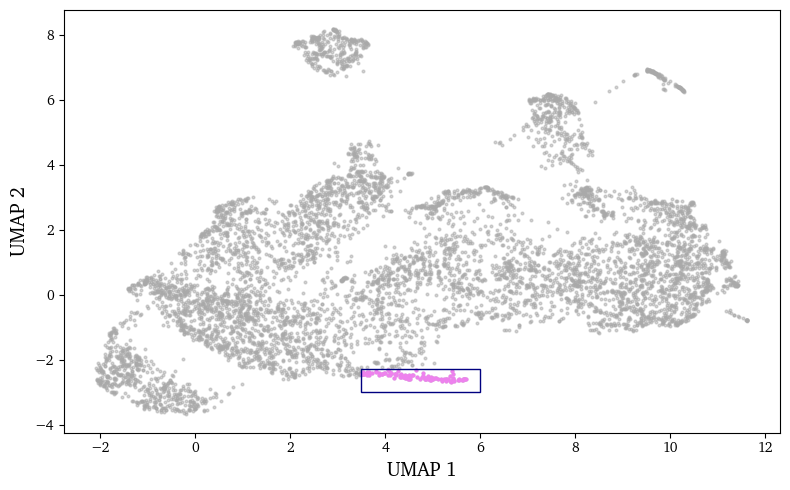

In [149]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(3.5, 6), umap_ylim=(-3, -2.3))

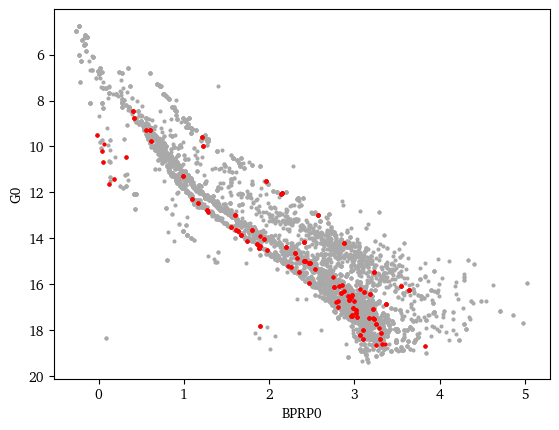

In [150]:
plot_cmd(mask_x, mask_y)

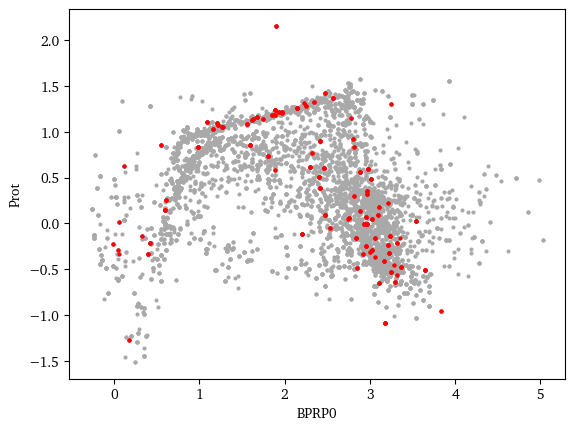

In [151]:
plot_prot(mask_x, mask_y)

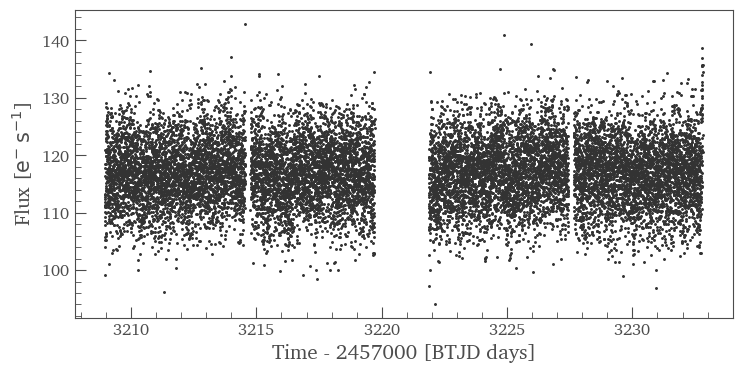

In [190]:
matching_indices = np.where(mask_x & mask_y)[0]
idx = np.random.choice(matching_indices)
tic = tic_ids[idx]
sector = sectors[idx]
res = lk.search_lightcurve(f"TIC {tic}", mission='TESS', author=['SPOC'],sector=sector,exptime=120)
lc = res[0].download()
lc.scatter(s=5,label='',marker='.')
plt.show()

## Binarity?

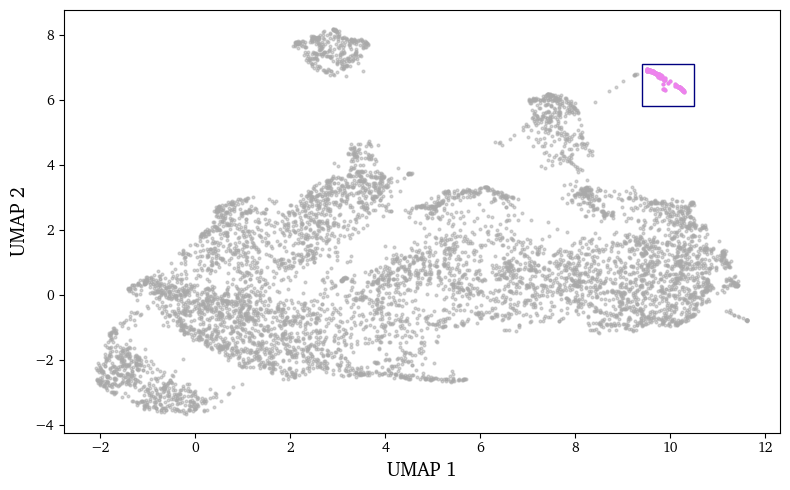

In [127]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(9.4, 10.5), umap_ylim=(5.8, 7.1))

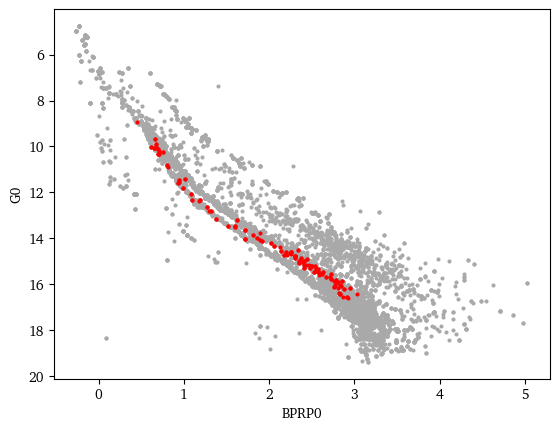

In [128]:
plot_cmd(mask_x, mask_y)

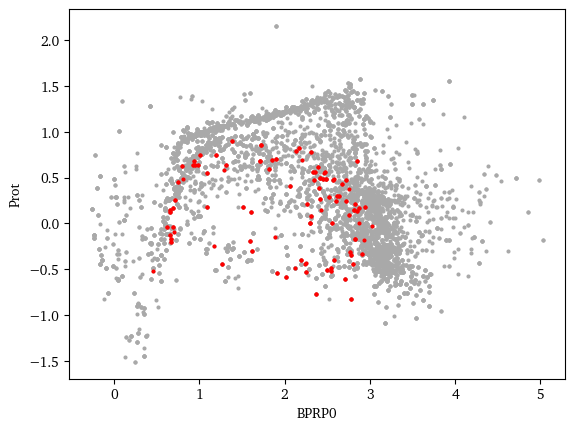

In [129]:
plot_prot(mask_x, mask_y)

### Pre-Main sequence

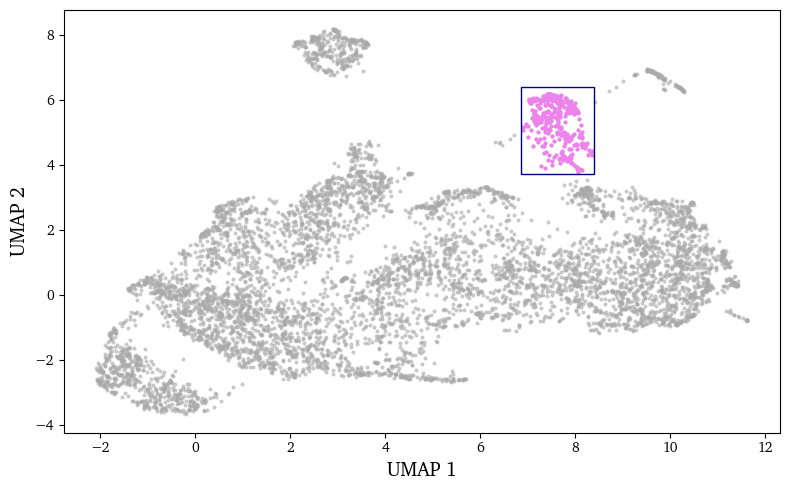

In [198]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(6.85, 8.4), umap_ylim=(3.7, 6.4))

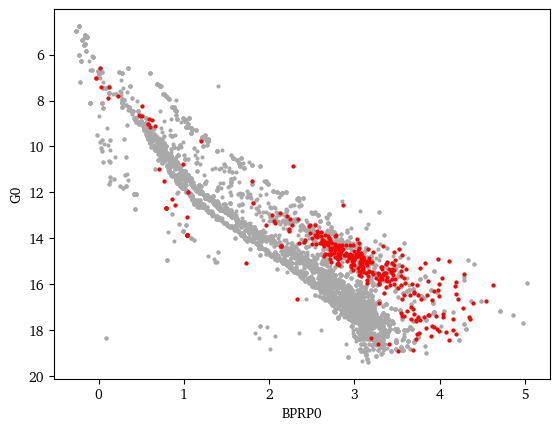

In [199]:
plot_cmd(mask_x, mask_y)

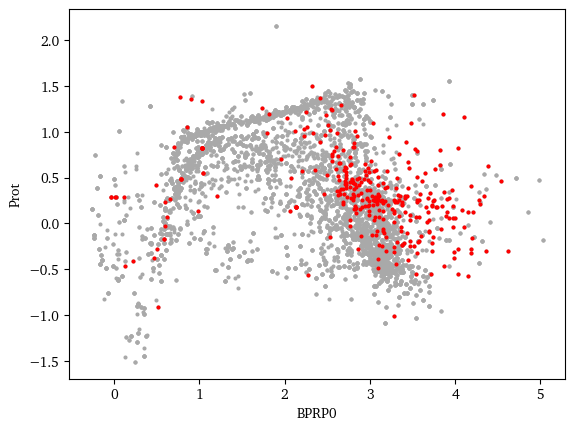

In [200]:
plot_prot(mask_x, mask_y)

## Something in light curve?

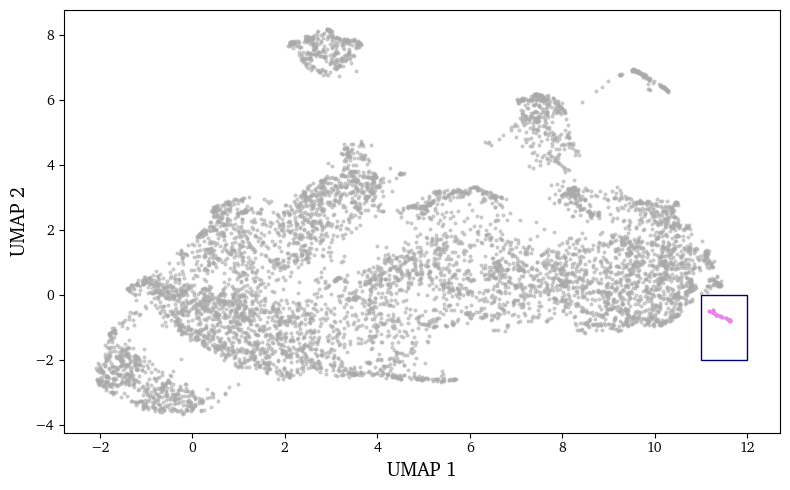

In [118]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(11, 12), umap_ylim=(-2, 0))

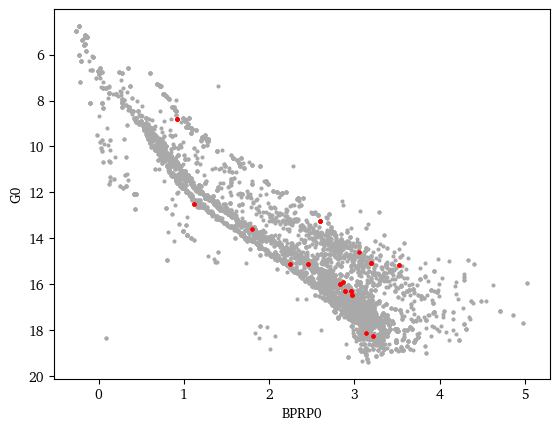

In [119]:
plot_cmd(mask_x, mask_y)

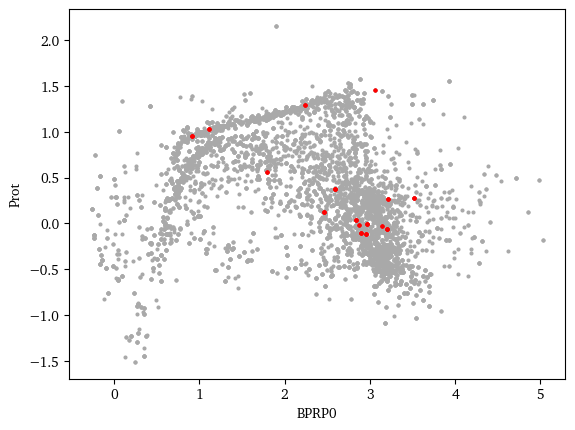

In [120]:
plot_prot(mask_x, mask_y)

### Inspect matching points

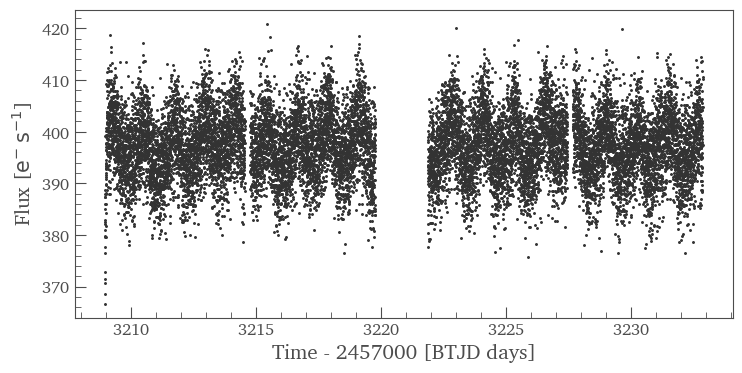

In [175]:
matching_indices = np.where(mask_x & mask_y)[0]
idx = np.random.choice(matching_indices)
tic = tic_ids[idx]
sector = sectors[idx]
res = lk.search_lightcurve(f"TIC {tic}", mission='TESS', author=['SPOC'],sector=sector,exptime=120)
lc = res[0].download()
lc.scatter(s=5,label='',marker='.')
plt.show()

## Look for high mass stars

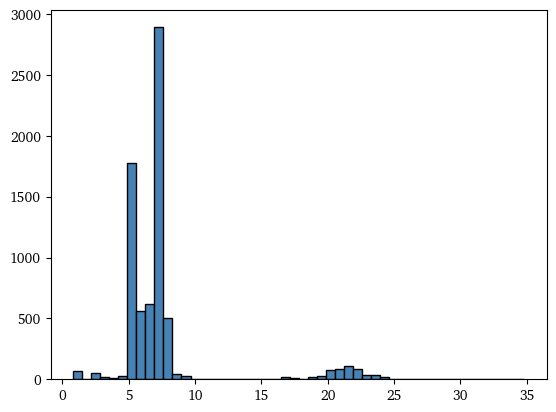

In [202]:
plt.hist(df['parallax'], bins=50, color='steelblue', edgecolor='black')
plt.show()

In [201]:
df

,GaiaDR3_ID,tic,num_refs,Prot,mem_prob_val,age_Myr,parallax,parallax_error,G0,G0_err,BP0,BP0_err,RP0,RP0_err,BPRP0,BPRP0_err
0,117709729140216320,405461319,2,6.484,0.929,112.2,6.559600,0.015855,11.681048,0.011626,12.110080,0.012618,11.086786,0.011007,1.023294,0.016744
1,117709729140216320,405461319,2,6.484,0.929,112.2,6.559600,0.015855,11.681048,0.011626,12.110080,0.012618,11.086786,0.011007,1.023294,0.016744
2,144171233106399104,456945485,1,9.164,1.000,775.0,21.744518,0.020119,8.404495,0.010005,8.769614,0.010044,7.868650,0.010019,0.900964,0.014187
3,144171233106399104,456945485,1,9.164,1.000,775.0,21.744518,0.020119,8.404495,0.010005,8.769614,0.010044,7.868650,0.010019,0.900964,0.014187
4,144171233106399104,456945485,1,9.164,1.000,775.0,21.744518,0.020119,8.404495,0.010005,8.769614,0.010044,7.868650,0.010019,0.900964,0.014187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7149,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592
7150,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592
7151,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592
7152,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592


In [203]:
hm_gids = df.loc[df['parallax'] > 15, 'GaiaDR3_ID'].values

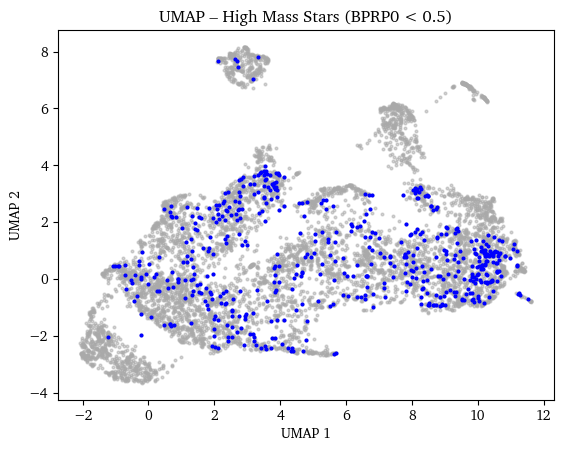

In [204]:
mask = [gid in hm_gids for gid in gaia_ids]
umap_hm = embedding[mask]
plt.scatter(embedding[:, 0], embedding[:, 1], color='darkgrey', s=15, alpha=0.5, marker='.')
plt.scatter(umap_hm[:, 0], umap_hm[:, 1], color='blue', s=15, alpha=1, marker='.')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP – High Mass Stars (BPRP0 < 0.5)')
plt.show()

# Composite UMAP with both regions

In [228]:
umap_xlim_fr = [9.4,10.5]
umap_ylim_fr = [5.8,7.1]

umap_xlim_pms=[6.85, 8.4]
umap_ylim_pms=[3.7, 6.4]


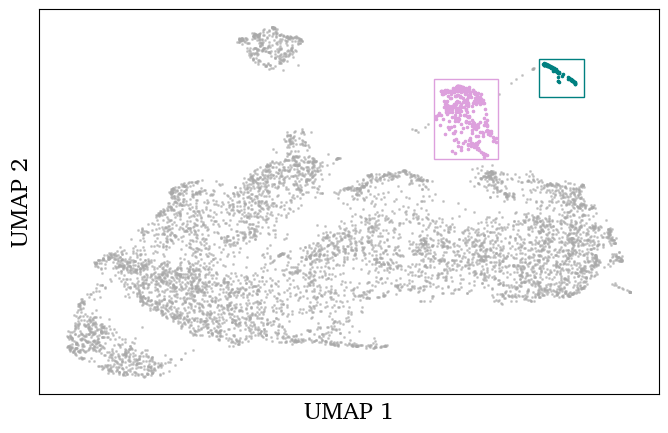

In [ ]:
rect_fr = patches.Rectangle(
    (umap_xlim_fr[0], umap_ylim_fr[0]),        # (x0, y0) lower-left corner
    umap_xlim_fr[1] - umap_xlim_fr[0],       # width
    umap_ylim_fr[1] - umap_ylim_fr[0],       # height
    edgecolor='teal',
    alpha=1,
    facecolor='none',
    linewidth=2
)

rec_pms = patches.Rectangle(
    (umap_xlim_pms[0], umap_ylim_pms[0]),        # (x0, y0) lower-left corner
    umap_xlim_pms[1] - umap_xlim_pms[0],       # width
    umap_ylim_pms[1] - umap_ylim_pms[0],       # height
    edgecolor='plum',
    alpha=1,
    facecolor='none',
    linewidth=2
)

mask_x_fr = (embedding[:, 0] < umap_xlim_fr[1]) & (embedding[:, 0] > umap_xlim_fr[0])
mask_y_fr = (embedding[:, 1] < umap_ylim_fr[1]) & (embedding[:, 1] > umap_ylim_fr[0])

mask_x_pms = (embedding[:, 0] < umap_xlim_pms[1]) & (embedding[:, 0] > umap_xlim_pms[0])
mask_y_pms = (embedding[:, 1] < umap_ylim_pms[1]) & (embedding[:, 1] > umap_ylim_pms[0])

x_all = embedding[:, 0]
y_all = embedding[:, 1]

x_p = embedding[mask_x_fr & mask_y_fr, 0]
y_p = embedding[mask_x_fr & mask_y_fr, 1]

x_pms = embedding[mask_x_pms & mask_y_pms, 0]
y_pms = embedding[mask_x_pms & mask_y_pms, 1]

fig, ax = plt.subplots(figsize=(8,5))
sc = ax.scatter(x_all,y_all, color='darkgrey', s=5, alpha=0.5, marker='.')
sc = ax.scatter(x_p, y_p, color='teal', s=10, alpha=1, marker='.',label='fast rotators')
sc = ax.scatter(x_pms, y_pms, color='plum', s=10, alpha=1, marker='.',label='slow rotators')
ax.add_patch(rect_fr)
ax.add_patch(rec_pms)
plt.xlabel('UMAP 1',fontsize=18)
plt.ylabel('UMAP 2',fontsize=18)
ax.set_xticks([])
ax.set_yticks([])
# plt.legend()

plt.show()